## Algorithmic Selector
### Random Forest

In [46]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("SGP_dataset.csv")

print(f"Number of instances not solved in time limit: "
      f"{(df['winner'] == 'none').sum()} / "
      f"{(((df['winner'] == 'none').sum()) * 100/df['winner'].count()):.0f}%")

df_cleaned = df[df['winner'] != 'none']

y = df_cleaned["winner"]

feature_cols = [
    "num_golfers",
    "num_weeks",
    "group_size",
    "tightness_T",
    "probe_conflicts",
]

X = df_cleaned[feature_cols]

# Split 65% Train, 35% Test, per assignment definition
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print("Accuracy:", classifier.score(X_test, y_test))

Number of instances not solved in time limit: 44 / 22%
Accuracy: 0.9090909090909091


### Confusion Matrix

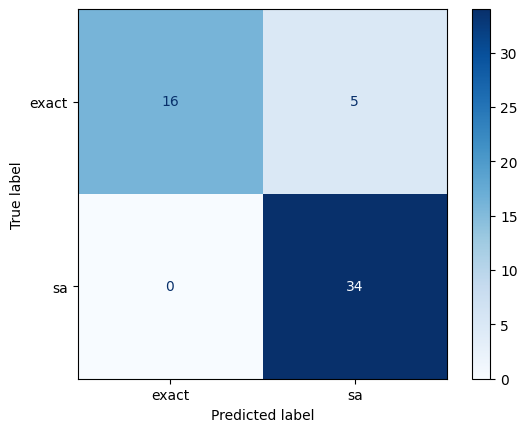

In [34]:
labels = np.unique(y_test)
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.show()

### Method Comparison

{'sa': np.int64(157), 'exact': np.int64(133), 'selector': np.int64(290)}


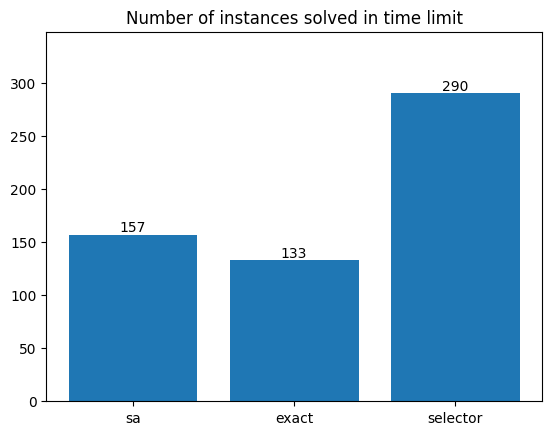

In [35]:
# Goal: Bar graph which shows for each method (Heuristic, CP, Algorithmic Selector) number of instances solved in time constraint .

num_solved_instances = {}

sa_finished_feat = 'sa_finished'
exact_finished_feat = 'exact_finished'

num_solved_instances['sa']= df_cleaned[exact_finished_feat].sum()
num_solved_instances['exact'] = df_cleaned[sa_finished_feat].sum()
num_solved_instances['selector'] = df_cleaned[exact_finished_feat].sum() + df_cleaned[sa_finished_feat].sum()

print(num_solved_instances)

# Plot
fig, ax = plt.subplots()

bars = ax.bar(
    range(len(num_solved_instances)),
    list(num_solved_instances.values()),
    align='center'
)

ax.set_xticks(range(len(num_solved_instances)))
ax.set_xticklabels(list(num_solved_instances.keys()))
ax.set_title('Number of instances solved in time limit')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

# Add headroom
ax.margins(y=0.2)

plt.show()

In [36]:
# Maybe more sophisticated graph? % Of runtime savings with selector? Maybe also include how many could not be solved.

### Feature Importance

tightness_T        0.286374
probe_conflicts    0.204425
num_golfers        0.203524
num_weeks          0.186302
group_size         0.119375
dtype: float64


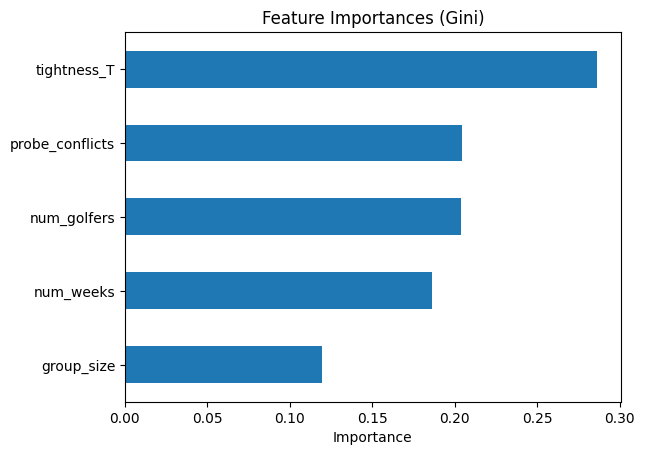

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# After training your model:
importances = classifier.feature_importances_
feature_names = X.columns

# Create a sorted series
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp)

# Plot
feat_imp.plot(kind="barh")
plt.title("Feature Importances (Gini)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

tightness_T        0.158788
probe_conflicts    0.116970
num_weeks          0.109697
num_golfers        0.107879
group_size         0.070303
dtype: float64


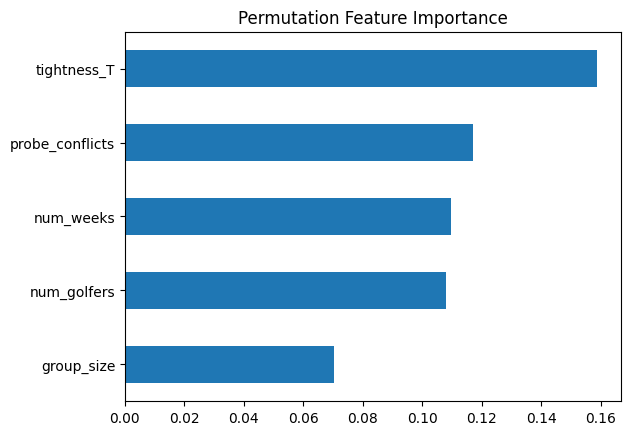

In [38]:
from sklearn.inspection import permutation_importance

result = permutation_importance(classifier, X_test, y_test, n_repeats=30, random_state=42)

perm_imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_imp)

perm_imp.plot(kind="barh")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.show()